# Branch Length Estimation - `maxregcount` GPU Optimization Analysis

Comparing the **optimized GPU build** (`maxregcount`) against the **baseline** results from `2026_03_13_branch_length_estimation`.

- **Optimized GPU**: `ci-cd-optimize/builds/build-nvhpc-openacc` (maxregcount)
- **Baseline GPU**: `ci-cd-cuda/builds/build-nvhpc-openacc` (standard)
- **Baseline CPU**: VANILA (1-core), OMP_10, OMP_48

Models tested: AA/LG (unrooted, 8 trees) and DNA/GTR (unrooted, 6 trees)  
100 taxa, 1M sites, 10 runs each

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120

OPT_DIR = Path('/Users/u7826985/Projects/Nvidia/results/2026_03_13_branch_length_estimation_opt')
BASELINE_DIR = Path('/Users/u7826985/Projects/Nvidia/results/2026_03_13_branch_length_estimation')
SAVE_DIR = Path('.')

## 1. Parse Log Files

In [2]:
def parse_log(filepath):
    """Extract metrics from an IQ-TREE log file."""
    try:
        with open(filepath, 'r') as f:
            text = f.read()
    except Exception:
        return None
    
    result = {}
    
    m = re.search(r'Total wall-clock time used:\s+([\d.]+)\s+sec', text)
    if m:
        result['walltime'] = float(m.group(1))
    
    m = re.search(r'Total CPU time used:\s+([\d.]+)\s+sec', text)
    if m:
        result['cputime'] = float(m.group(1))
    
    m = re.search(r'BEST SCORE FOUND\s*:\s*([\-\d.]+)', text)
    if m:
        result['log_likelihood'] = float(m.group(1))
    
    m = re.search(r'Total tree length:\s+([\d.]+)', text)
    if m:
        result['tree_length'] = float(m.group(1))
    
    m = re.search(r'Parameters optimization took \d+ rounds \(([\d.]+) sec\)', text)
    if m:
        result['opt_time'] = float(m.group(1))
    
    return result if 'walltime' in result else None


def extract_run_number(filename):
    matches = re.findall(r'_run(\d+)_', filename)
    if matches:
        return int(matches[-1])
    return None


def classify_backend(filename):
    if 'OPENACC' in filename:
        return 'OPENACC'
    elif 'VANILA' in filename:
        return 'VANILA'
    elif 'OMP_48' in filename:
        return 'OMP_48'
    elif 'OMP_10' in filename:
        return 'OMP_10'
    return 'UNKNOWN'


def parse_results_dir(base_dir, source_label):
    rows = []
    for data_type in ['AA', 'DNA']:
        for tree_type in ['rooted', 'unrooted']:
            type_dir = base_dir / data_type / tree_type
            if not type_dir.exists():
                continue
            for model_dir in sorted(type_dir.iterdir()):
                if not model_dir.is_dir():
                    continue
                model = model_dir.name
                for tree_dir in sorted(model_dir.iterdir()):
                    if not tree_dir.is_dir():
                        continue
                    tree = tree_dir.name
                    for logfile in tree_dir.glob('*.log'):
                        fname = logfile.name
                        backend = classify_backend(fname)
                        run_num = extract_run_number(fname)
                        metrics = parse_log(logfile)
                        if metrics:
                            rows.append({
                                'source': source_label,
                                'data_type': data_type,
                                'tree_type': tree_type,
                                'model': model,
                                'tree': tree,
                                'backend': backend,
                                'run': run_num,
                                **metrics
                            })
    return rows

In [3]:
# Parse optimized GPU results
opt_rows = parse_results_dir(OPT_DIR, 'GPU_OPT')
df_opt = pd.DataFrame(opt_rows)
print(f'Optimized GPU: {len(df_opt)} log entries')
print(df_opt.groupby(['data_type', 'model', 'tree']).size().reset_index(name='n_runs'))

# Parse baseline results (only AA/LG and DNA/GTR, unrooted)
base_rows = parse_results_dir(BASELINE_DIR, 'baseline')
df_base = pd.DataFrame(base_rows)
# Filter to matching models
df_base = df_base[
    (df_base['tree_type'] == 'unrooted') &
    (
        ((df_base['data_type'] == 'AA') & (df_base['model'] == 'LG')) |
        ((df_base['data_type'] == 'DNA') & (df_base['model'] == 'GTR'))
    )
].copy()
print(f'\nBaseline (filtered): {len(df_base)} log entries')
print(df_base.groupby(['data_type', 'model', 'backend']).size().reset_index(name='n_runs'))

Optimized GPU: 120 log entries
   data_type model    tree  n_runs
0         AA    LG  tree_1      10
1         AA    LG  tree_2      10
2         AA    LG  tree_3      10
3         AA    LG  tree_4      10
4         AA    LG  tree_5      10
5         AA    LG  tree_6      10
6         AA    LG  tree_7      10
7        DNA   GTR  tree_1      10
8        DNA   GTR  tree_2      10
9        DNA   GTR  tree_3      10
10       DNA   GTR  tree_4      10
11       DNA   GTR  tree_5      10



Baseline (filtered): 687 log entries
  data_type model  backend  n_runs
0        AA    LG   OMP_10     100
1        AA    LG   OMP_48     100
2        AA    LG  OPENACC     137
3        AA    LG   VANILA      20
4       DNA   GTR   OMP_10     100
5       DNA   GTR   OMP_48     100
6       DNA   GTR  OPENACC      90
7       DNA   GTR   VANILA      40


In [4]:
# Relabel backends for combined dataframe
df_opt_labeled = df_opt.copy()
df_opt_labeled['backend'] = 'GPU_OPT'

df_combined = pd.concat([df_base, df_opt_labeled], ignore_index=True)
df_combined.to_csv(SAVE_DIR / 'results_combined.csv', index=False)
print(f'Combined: {len(df_combined)} entries')
print(df_combined.groupby(['data_type', 'backend']).size().unstack(fill_value=0))

Combined: 807 entries
backend    GPU_OPT  OMP_10  OMP_48  OPENACC  VANILA
data_type                                          
AA              70     100     100      137      20
DNA             50     100     100       90      40


## 2. Summary Statistics

In [5]:
summary = df_combined.groupby(['data_type', 'model', 'backend']).agg(
    walltime_mean=('walltime', 'mean'),
    walltime_median=('walltime', 'median'),
    walltime_std=('walltime', 'std'),
    walltime_min=('walltime', 'min'),
    walltime_max=('walltime', 'max'),
    opt_time_mean=('opt_time', 'mean'),
    logl_mean=('log_likelihood', 'mean'),
    logl_std=('log_likelihood', 'std'),
    n_runs=('walltime', 'count')
).round(3)

summary.to_csv(SAVE_DIR / 'results_summary.csv')
summary

walltime_mean  walltime_median  walltime_std  \
data_type model backend                                                 
AA        LG    GPU_OPT         29.486           30.248         2.329   
                OMP_10          40.597           38.558         9.580   
                OMP_48          15.457           15.020         2.398   
                OPENACC         29.859           30.599         2.427   
                VANILA         251.787          250.290        33.784   
DNA       GTR   GPU_OPT         48.685           48.264         5.991   
                OMP_10          38.111           34.237        14.922   
                OMP_48          16.185           15.054         4.098   
                OPENACC         50.172           49.356         6.565   
                VANILA         133.017          121.995        22.931   

                         walltime_min  walltime_max  opt_time_mean  \
data_type model backend                                              
AA        LG    GPU_OPT        23.393        31.885         26.588   
                OMP_10         28.444        67.275         39.260   
                OMP_48         11.250        20.561         14.026   
                OPENACC        23.594        32.290         26.954   
                VANILA        212.665       291.329        248.778   
DNA       GTR   GPU_OPT        42.190        60.852         45.921   
                OMP_10         19.758        92.248         36.906   
                OMP_48          9.970        24.545         15.061   
                OPENACC        43.421        63.452         47.367   
                VANILA        111.904       177.733        130.275   

                            logl_mean     logl_std  n_runs  
data_type model backend                                     
AA        LG    GPU_OPT -8.747060e+07  1812371.109      70  
                OMP_10  -8.632801e+07  2605043.269     100  
                OMP_48  -8.632801e+07  2605043.269     100  
                OPENACC -8.747797e+07  1824949.805     137  
                VANILA  -8.970307e+07   822470.828      20  
DNA       GTR   GPU_OPT -6.683769e+07  1560312.560      50  
                OMP_10  -6.743701e+07  2633938.757     100  
                OMP_48  -6.743701e+07  2633938.757     100  
                OPENACC -6.670245e+07  1579812.307      90  
                VANILA  -6.653339e+07  1607473.986      40

## 3. Verify Likelihood Consistency

In [6]:
# Check per tree that all backends produce the same likelihood
# Only compare trees that exist in both opt and baseline
opt_trees = set(df_opt[['data_type', 'model', 'tree']].apply(tuple, axis=1))

df_check = df_combined[df_combined[['data_type', 'model', 'tree']].apply(tuple, axis=1).isin(opt_trees)]
logl_check = df_check.groupby(['data_type', 'model', 'tree']).agg(
    logl_min=('log_likelihood', 'min'),
    logl_max=('log_likelihood', 'max'),
    logl_range=('log_likelihood', lambda x: x.max() - x.min())
).reset_index()

mismatches = logl_check[logl_check['logl_range'] > 0.01]
if len(mismatches) == 0:
    print('All backends (including GPU_OPT) produce identical log-likelihoods (within 0.01).')
else:
    print(f'WARNING: {len(mismatches)} tree(s) with likelihood mismatches:')
    display(mismatches)

All backends (including GPU_OPT) produce identical log-likelihoods (within 0.01).


## 4. GPU Optimized vs Baseline GPU — Direct Comparison

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_56478/2005533358.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='walltime',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_56478/2005533358.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([backend_labels.get(b, b) for b in present_backends], fontsize=11)


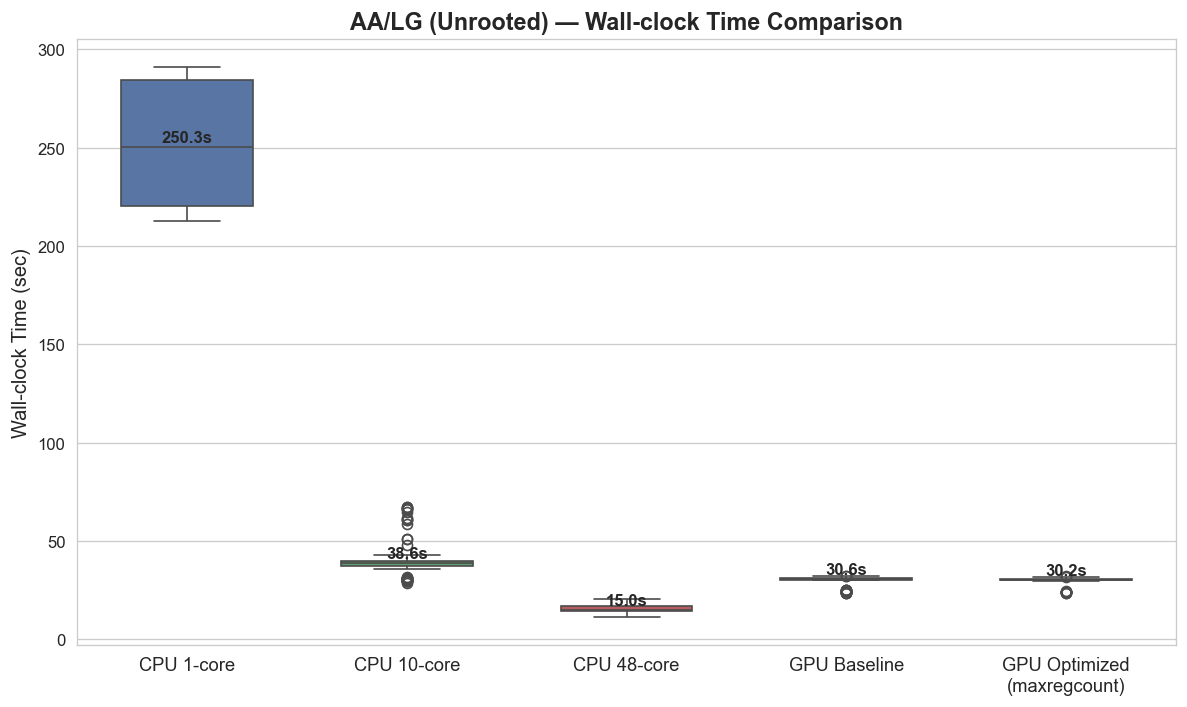

Saved: walltime_comparison_AA_LG.png


/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_56478/2005533358.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='walltime',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_56478/2005533358.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([backend_labels.get(b, b) for b in present_backends], fontsize=11)


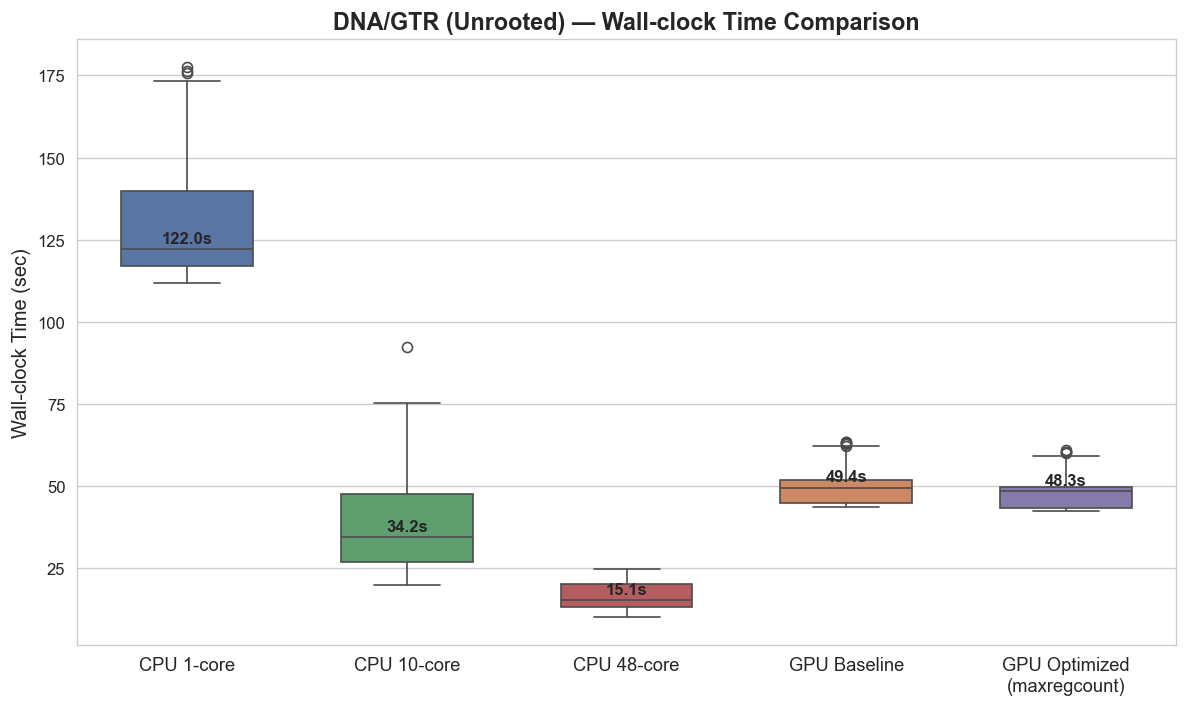

Saved: walltime_comparison_DNA_GTR.png


In [7]:
backend_order = ['VANILA', 'OMP_10', 'OMP_48', 'OPENACC', 'GPU_OPT']
backend_colors = {
    'VANILA': '#4C72B0',
    'OMP_10': '#55A868',
    'OMP_48': '#C44E52',
    'OPENACC': '#DD8452',
    'GPU_OPT': '#8172B2'
}
backend_labels = {
    'VANILA': 'CPU 1-core',
    'OMP_10': 'CPU 10-core',
    'OMP_48': 'CPU 48-core',
    'OPENACC': 'GPU Baseline',
    'GPU_OPT': 'GPU Optimized\n(maxregcount)'
}

for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    subset = df_combined[(df_combined['data_type'] == data_type) & (df_combined['model'] == model)]
    present_backends = [b for b in backend_order if b in subset['backend'].unique()]
    palette = [backend_colors[b] for b in present_backends]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(data=subset, x='backend', y='walltime',
               order=present_backends, palette=palette, ax=ax, width=0.6)
    
    ax.set_xticklabels([backend_labels.get(b, b) for b in present_backends], fontsize=11)
    ax.set_ylabel('Wall-clock Time (sec)', fontsize=12)
    ax.set_xlabel('')
    ax.set_title(f'{data_type}/{model} (Unrooted) — Wall-clock Time Comparison',
                fontsize=14, fontweight='bold')
    
    # Add median labels
    medians = subset.groupby('backend')['walltime'].median()
    for i, b in enumerate(present_backends):
        if b in medians.index:
            ax.text(i, medians[b] + 1, f'{medians[b]:.1f}s',
                   ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    fname = f'walltime_comparison_{data_type}_{model}.png'
    plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## 5. Speedup Analysis

In [8]:
# Compute median walltime per config
median_wt = df_combined.groupby(['data_type', 'model', 'tree', 'backend'])['walltime'].median().reset_index()
pivot = median_wt.pivot_table(index=['data_type', 'model', 'tree'],
                               columns='backend', values='walltime').reset_index()

# Speedups relative to VANILA
for backend in ['OMP_10', 'OMP_48', 'OPENACC', 'GPU_OPT']:
    if backend in pivot.columns and 'VANILA' in pivot.columns:
        pivot[f'speedup_{backend}'] = pivot['VANILA'] / pivot[backend]

# GPU_OPT improvement over baseline GPU
if 'GPU_OPT' in pivot.columns and 'OPENACC' in pivot.columns:
    pivot['gpu_improvement_pct'] = ((pivot['OPENACC'] - pivot['GPU_OPT']) / pivot['OPENACC'] * 100).round(2)

speedup_summary = pivot.groupby(['data_type', 'model']).agg({
    'speedup_OMP_10': ['mean', 'median'],
    'speedup_OMP_48': ['mean', 'median'],
    'speedup_OPENACC': ['mean', 'median'],
    'speedup_GPU_OPT': ['mean', 'median'],
    'gpu_improvement_pct': ['mean', 'median']
}).round(2)

speedup_summary.to_csv(SAVE_DIR / 'speedup_summary.csv')
speedup_summary

backend         speedup_OMP_10        speedup_OMP_48        speedup_OPENACC  \
                          mean median           mean median            mean   
data_type model                                                               
AA        LG              7.39   7.39          18.95  18.95            9.18   
DNA       GTR             4.30   4.55           8.84   8.87            2.63   

backend                speedup_GPU_OPT        gpu_improvement_pct         
                median            mean median                mean median  
data_type model                                                           
AA        LG      9.18            9.26   9.26                0.91   0.91  
DNA       GTR     2.64            2.71   2.72                2.73   2.65

## 6. Speedup Bar Chart — All Backends

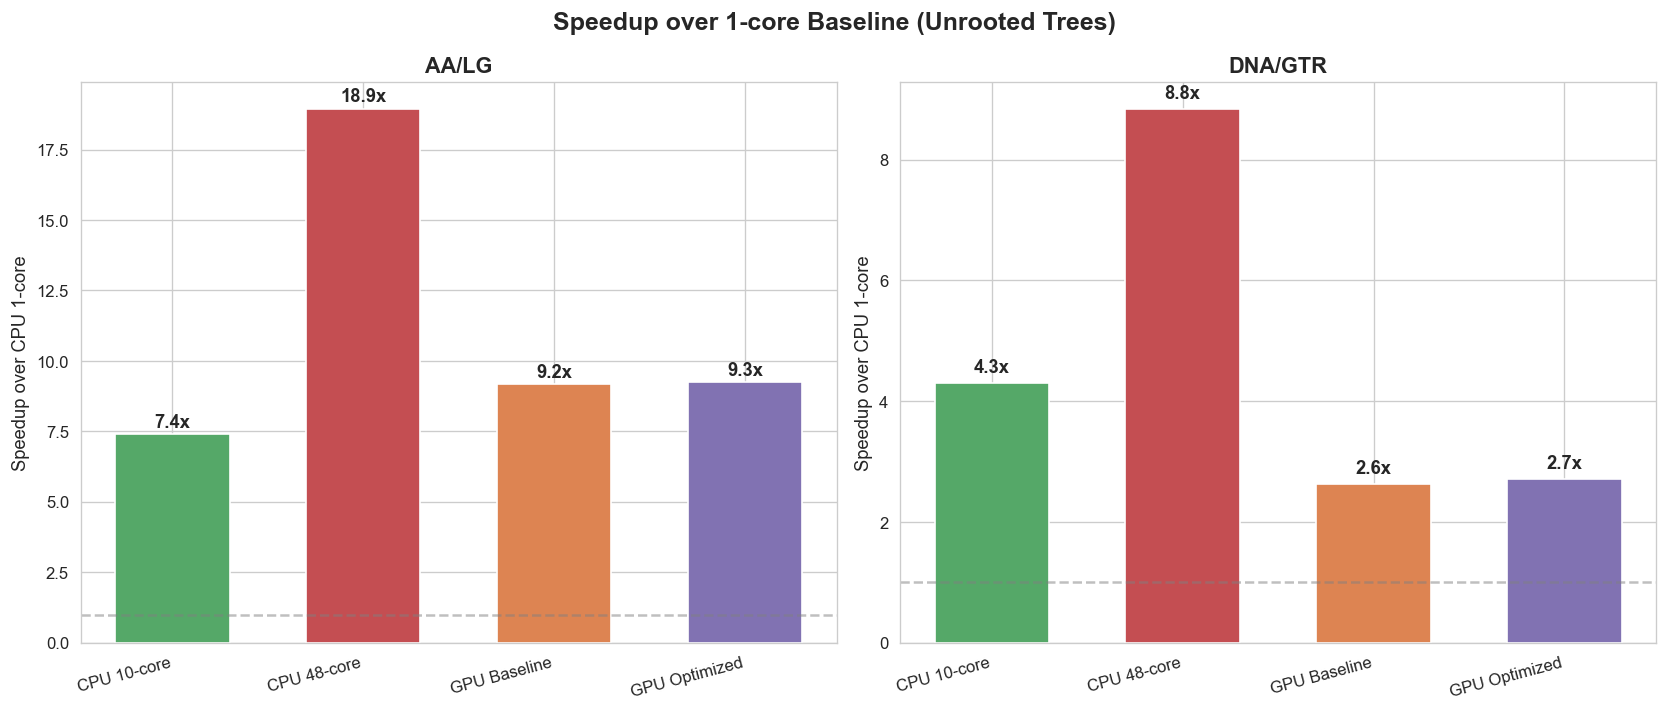

Saved: speedup_all_backends.png


In [9]:
speedup_backends = ['OMP_10', 'OMP_48', 'OPENACC', 'GPU_OPT']
speedup_bar_colors = {
    'OMP_10': '#55A868',
    'OMP_48': '#C44E52',
    'OPENACC': '#DD8452',
    'GPU_OPT': '#8172B2'
}
speedup_bar_labels = {
    'OMP_10': 'CPU 10-core',
    'OMP_48': 'CPU 48-core',
    'OPENACC': 'GPU Baseline',
    'GPU_OPT': 'GPU Optimized'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (data_type, model) in zip(axes, [('AA', 'LG'), ('DNA', 'GTR')]):
    sub = pivot[(pivot['data_type'] == data_type) & (pivot['model'] == model)]
    present_cols = [f'speedup_{b}' for b in speedup_backends if f'speedup_{b}' in sub.columns and sub[f'speedup_{b}'].notna().any()]
    
    mean_speedups = sub[present_cols].mean()
    
    bars = ax.bar(range(len(present_cols)), mean_speedups.values,
                 color=[speedup_bar_colors[c.replace('speedup_', '')] for c in present_cols],
                 width=0.6)
    
    for bar, val in zip(bars, mean_speedups.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
               f'{val:.1f}x', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax.set_xticks(range(len(present_cols)))
    ax.set_xticklabels([speedup_bar_labels[c.replace('speedup_', '')] for c in present_cols],
                       fontsize=10, rotation=15, ha='right')
    ax.set_ylabel('Speedup over CPU 1-core', fontsize=11)
    ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'{data_type}/{model}', fontsize=13, fontweight='bold')

fig.suptitle('Speedup over 1-core Baseline (Unrooted Trees)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'speedup_all_backends.png', bbox_inches='tight')
plt.show()
print('Saved: speedup_all_backends.png')

## 7. GPU Optimized vs Baseline GPU — Per-Tree Comparison

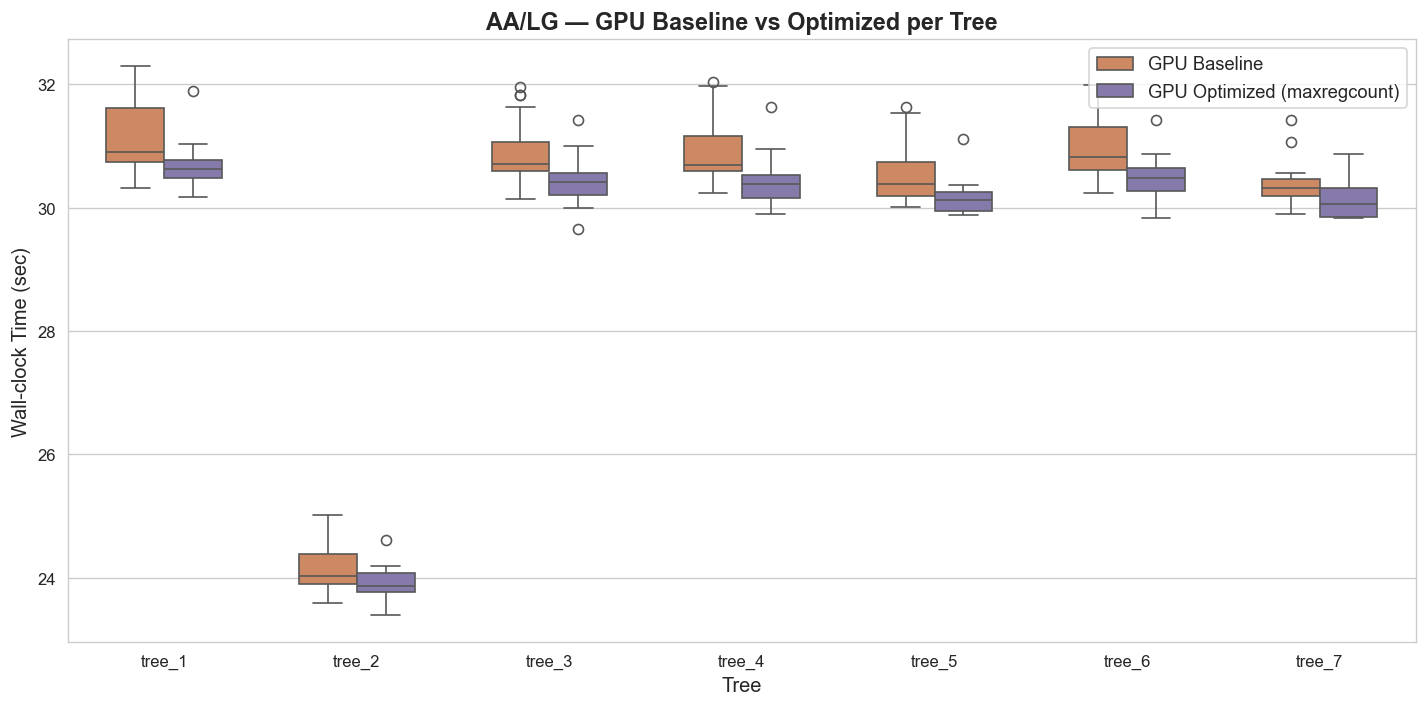

Saved: gpu_per_tree_AA_LG.png


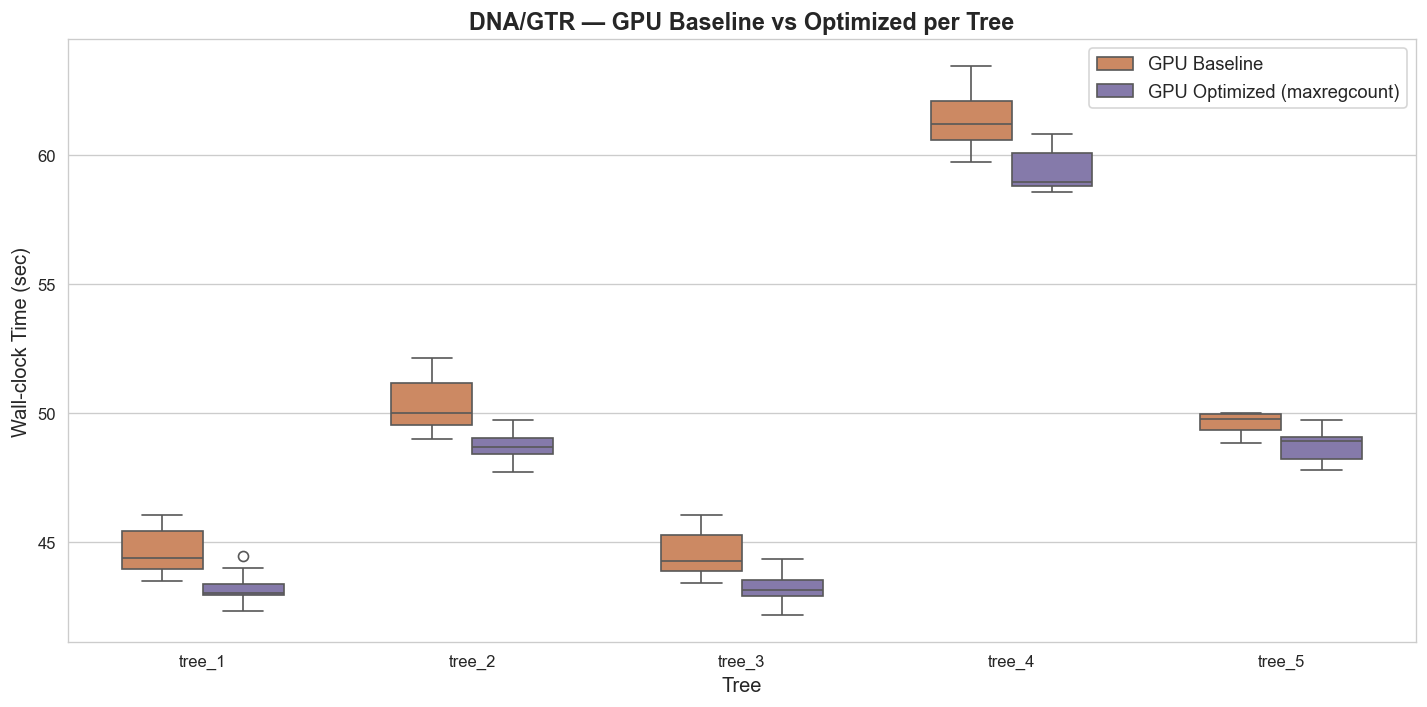

Saved: gpu_per_tree_DNA_GTR.png


In [10]:
for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    subset = df_combined[
        (df_combined['data_type'] == data_type) &
        (df_combined['model'] == model) &
        (df_combined['backend'].isin(['OPENACC', 'GPU_OPT']))
    ]
    if subset.empty:
        continue
    
    trees = sorted(subset['tree'].unique(), key=lambda x: int(x.split('_')[1]))
    
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=subset, x='tree', y='walltime', hue='backend',
               order=trees,
               hue_order=['OPENACC', 'GPU_OPT'],
               palette=[backend_colors['OPENACC'], backend_colors['GPU_OPT']],
               ax=ax, width=0.6)
    
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, ['GPU Baseline', 'GPU Optimized (maxregcount)'],
             fontsize=11, loc='upper right')
    ax.set_xlabel('Tree', fontsize=12)
    ax.set_ylabel('Wall-clock Time (sec)', fontsize=12)
    ax.set_title(f'{data_type}/{model} — GPU Baseline vs Optimized per Tree',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    fname = f'gpu_per_tree_{data_type}_{model}.png'
    plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## 8. GPU Improvement Percentage

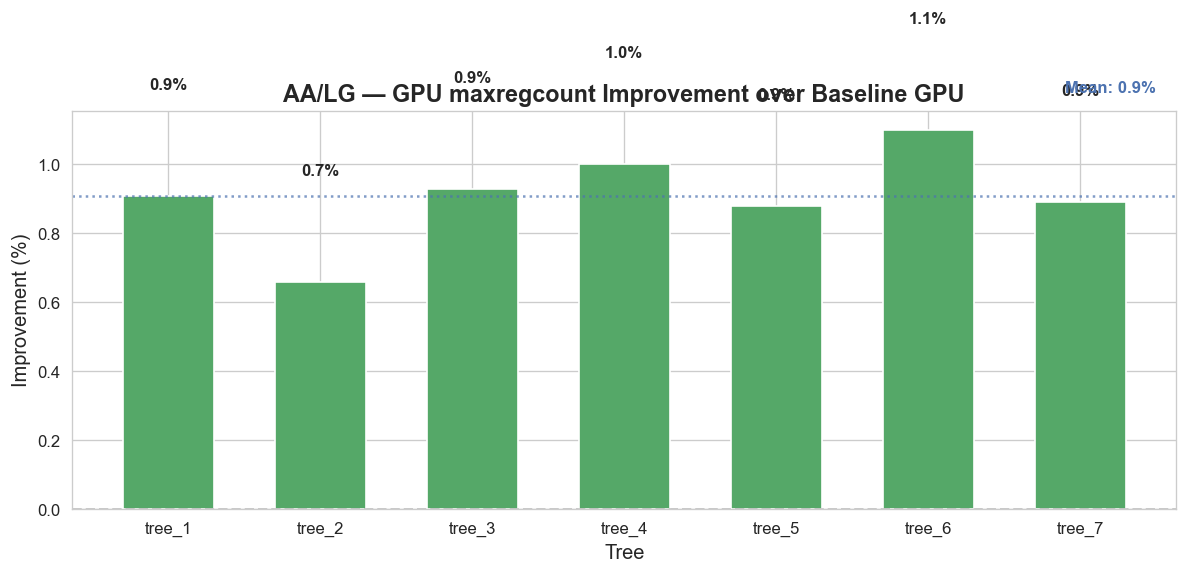

Saved: gpu_improvement_AA_LG.png


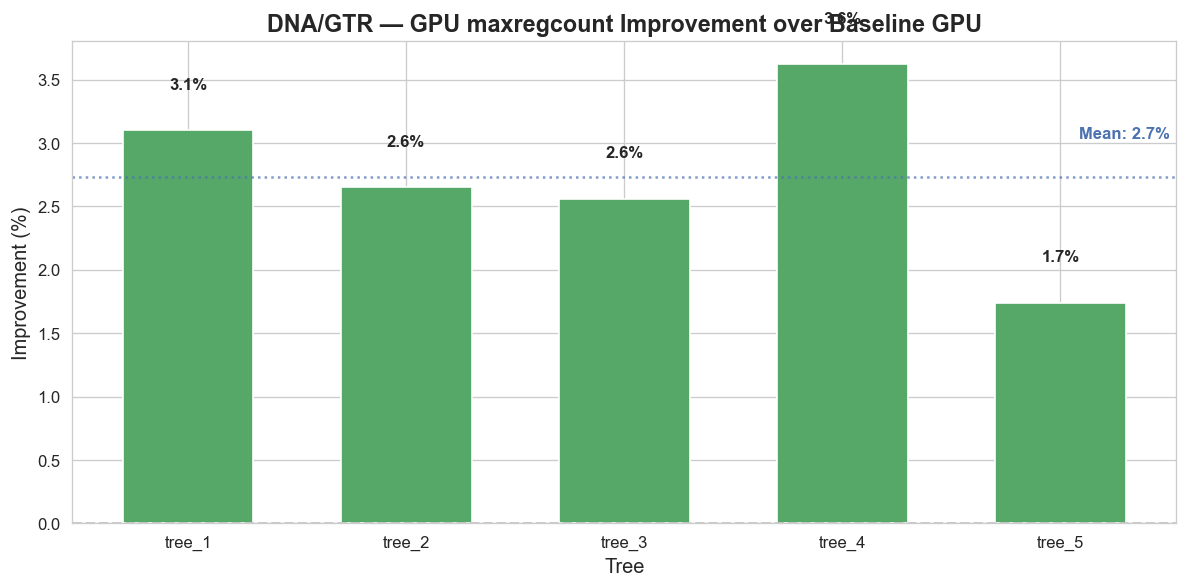

Saved: gpu_improvement_DNA_GTR.png

GPU Improvement Summary:


,,mean,median,min,max
data_type,model,,,,
AA,LG,0.91,0.91,0.66,1.10
DNA,GTR,2.73,2.65,1.74,3.62


In [11]:
# Per-tree GPU improvement
if 'gpu_improvement_pct' in pivot.columns:
    improvement = pivot[['data_type', 'model', 'tree', 'OPENACC', 'GPU_OPT', 'gpu_improvement_pct']].dropna()
    improvement = improvement.sort_values(['data_type', 'model', 'tree'])
    
    for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
        sub = improvement[(improvement['data_type'] == data_type) & (improvement['model'] == model)]
        if sub.empty:
            continue
        
        trees = sorted(sub['tree'].values, key=lambda x: int(x.split('_')[1]))
        sub_sorted = sub.set_index('tree').loc[trees]
        
        fig, ax = plt.subplots(figsize=(10, 5))
        colors = ['#55A868' if v > 0 else '#C44E52' for v in sub_sorted['gpu_improvement_pct']]
        bars = ax.bar(range(len(trees)), sub_sorted['gpu_improvement_pct'].values,
                     color=colors, width=0.6)
        
        for bar, val in zip(bars, sub_sorted['gpu_improvement_pct'].values):
            ax.text(bar.get_x() + bar.get_width() / 2,
                   bar.get_height() + (0.3 if val >= 0 else -1.5),
                   f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        ax.set_xticks(range(len(trees)))
        ax.set_xticklabels(trees, fontsize=10)
        ax.set_ylabel('Improvement (%)', fontsize=12)
        ax.set_xlabel('Tree', fontsize=12)
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        ax.set_title(f'{data_type}/{model} — GPU maxregcount Improvement over Baseline GPU',
                    fontsize=14, fontweight='bold')
        
        mean_imp = sub_sorted['gpu_improvement_pct'].mean()
        ax.axhline(y=mean_imp, color='#4C72B0', linestyle=':', alpha=0.7)
        ax.text(len(trees) - 0.5, mean_imp + 0.3, f'Mean: {mean_imp:.1f}%',
               fontsize=10, color='#4C72B0', fontweight='bold', ha='right')
        
        plt.tight_layout()
        fname = f'gpu_improvement_{data_type}_{model}.png'
        plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
        plt.show()
        print(f'Saved: {fname}')
    
    improvement.to_csv(SAVE_DIR / 'gpu_improvement.csv', index=False)
    print('\nGPU Improvement Summary:')
    display(improvement.groupby(['data_type', 'model'])['gpu_improvement_pct'].agg(['mean', 'median', 'min', 'max']).round(2))

## 9. Optimization Time: Baseline GPU vs Optimized GPU

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_56478/2518421006.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='opt_time',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_56478/2518421006.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['GPU Baseline', 'GPU Optimized\n(maxregcount)'], fontsize=11)


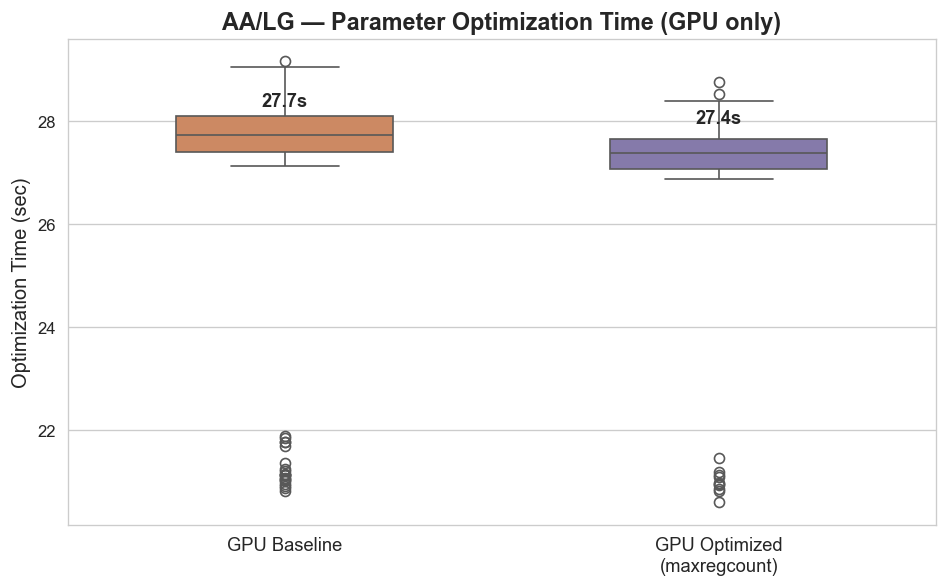

Saved: opt_time_gpu_AA_LG.png


/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_56478/2518421006.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='opt_time',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_56478/2518421006.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['GPU Baseline', 'GPU Optimized\n(maxregcount)'], fontsize=11)


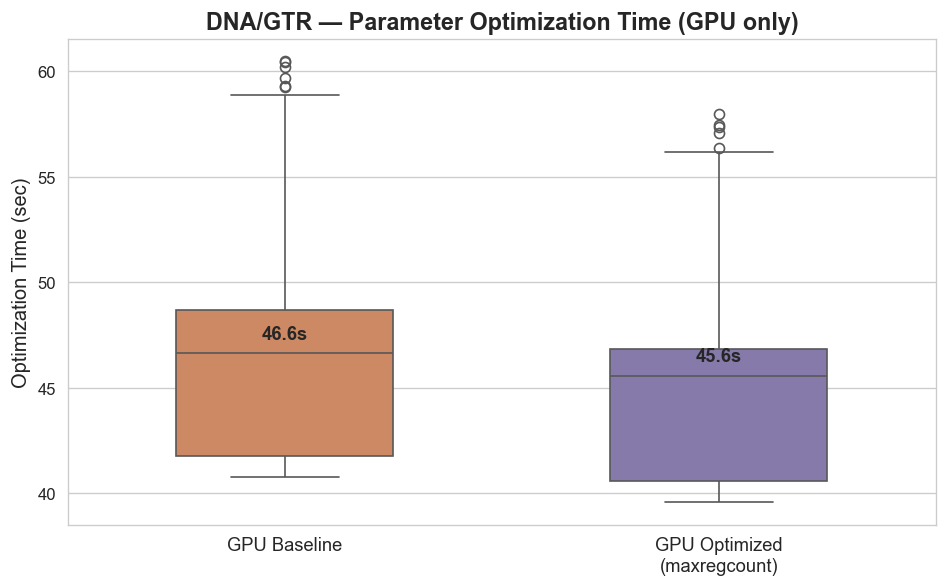

Saved: opt_time_gpu_DNA_GTR.png


In [12]:
gpu_only = df_combined[df_combined['backend'].isin(['OPENACC', 'GPU_OPT'])].dropna(subset=['opt_time'])

for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    subset = gpu_only[(gpu_only['data_type'] == data_type) & (gpu_only['model'] == model)]
    if subset.empty:
        continue
    
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(data=subset, x='backend', y='opt_time',
               order=['OPENACC', 'GPU_OPT'],
               palette=[backend_colors['OPENACC'], backend_colors['GPU_OPT']],
               ax=ax, width=0.5)
    
    ax.set_xticklabels(['GPU Baseline', 'GPU Optimized\n(maxregcount)'], fontsize=11)
    ax.set_ylabel('Optimization Time (sec)', fontsize=12)
    ax.set_xlabel('')
    ax.set_title(f'{data_type}/{model} — Parameter Optimization Time (GPU only)',
                fontsize=14, fontweight='bold')
    
    medians = subset.groupby('backend')['opt_time'].median()
    for i, b in enumerate(['OPENACC', 'GPU_OPT']):
        if b in medians.index:
            ax.text(i, medians[b] + 0.5, f'{medians[b]:.1f}s',
                   ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    plt.tight_layout()
    fname = f'opt_time_gpu_{data_type}_{model}.png'
    plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## 10. Final Summary Table

In [13]:
final = df_combined.groupby(['data_type', 'model', 'backend']).agg(
    mean_walltime=('walltime', 'mean'),
    median_walltime=('walltime', 'median'),
    std_walltime=('walltime', 'std'),
    mean_opt_time=('opt_time', 'mean'),
    n_runs=('walltime', 'count')
).round(2).reset_index()

# Add speedup vs VANILA
vanila = final[final['backend'] == 'VANILA'][['data_type', 'model', 'median_walltime']].rename(
    columns={'median_walltime': 'vanila_median'})
final = final.merge(vanila, on=['data_type', 'model'], how='left')
final['speedup_vs_1core'] = (final['vanila_median'] / final['median_walltime']).round(2)

# Add speedup vs baseline GPU
gpu_base = final[final['backend'] == 'OPENACC'][['data_type', 'model', 'median_walltime']].rename(
    columns={'median_walltime': 'gpu_base_median'})
final = final.merge(gpu_base, on=['data_type', 'model'], how='left')
final['speedup_vs_gpu_base'] = (final['gpu_base_median'] / final['median_walltime']).round(2)

final = final.drop(columns=['vanila_median', 'gpu_base_median'])
final.to_csv(SAVE_DIR / 'final_summary.csv', index=False)

display(final.style.format({
    'speedup_vs_1core': '{:.2f}x',
    'speedup_vs_gpu_base': '{:.2f}x'
}).background_gradient(subset=['speedup_vs_1core'], cmap='Greens')
 .background_gradient(subset=['speedup_vs_gpu_base'], cmap='Purples'))

,data_type,model,backend,mean_walltime,median_walltime,std_walltime,mean_opt_time,n_runs,speedup_vs_1core,speedup_vs_gpu_base
0,AA,LG,GPU_OPT,29.490000,30.250000,2.330000,26.590000,70,8.27x,1.01x
1,AA,LG,OMP_10,40.600000,38.560000,9.580000,39.260000,100,6.49x,0.79x
2,AA,LG,OMP_48,15.460000,15.020000,2.400000,14.030000,100,16.66x,2.04x
3,AA,LG,OPENACC,29.860000,30.600000,2.430000,26.950000,137,8.18x,1.00x
4,AA,LG,VANILA,251.790000,250.290000,33.780000,248.780000,20,1.00x,0.12x
5,DNA,GTR,GPU_OPT,48.680000,48.260000,5.990000,45.920000,50,2.53x,1.02x
6,DNA,GTR,OMP_10,38.110000,34.240000,14.920000,36.910000,100,3.56x,1.44x
7,DNA,GTR,OMP_48,16.180000,15.050000,4.100000,15.060000,100,8.11x,3.28x
8,DNA,GTR,OPENACC,50.170000,49.360000,6.570000,47.370000,90,2.47x,1.00x
9,DNA,GTR,VANILA,133.020000,122.000000,22.930000,130.280000,40,1.00x,0.40x
